# 🚀 Ensemble Learning Homework — Spaceship Titanic

**Mục tiêu:** Khám phá dữ liệu Spaceship Titanic, huấn luyện nhiều mô hình học máy kết hợp
kỹ thuật Ensemble Learning (**Bagging / Boosting / Stacking**), benchmark và so sánh các
mô hình với nhau, sau đó dự đoán trên tập test để nộp lên Kaggle.

**Bài toán:** Binary classification — dự đoán cột `Transported` (hành khách có bị "dịch chuyển"
sang chiều không gian khác hay không) dựa trên các thông tin cá nhân và hồ sơ chi tiêu trên tàu.

**Nội dung notebook:**
1. Khám phá dữ liệu (EDA)
2. Tiền xử lý & Feature Engineering
3. Xây dựng pipeline tiền xử lý
4. Baseline: Decision Tree đơn lẻ
5. **Bagging** (BaggingClassifier)
6. **Random Forest** (Bagging + Random Feature Selection)
7. **Boosting**: AdaBoost, Gradient Boosting, XGBoost (+ tinh chỉnh siêu tham số)
8. **Stacking & Voting**
9. So sánh benchmark tổng hợp
10. Huấn luyện mô hình tốt nhất trên toàn bộ train set & dự đoán trên test set
11. Xuất file submission cho Kaggle


In [1]:
# --- Thư viện cơ bản ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Thư viện scikit-learn ---
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, VotingClassifier, StackingClassifier
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- XGBoost ---
from xgboost import XGBClassifier

# --- Cấu hình chung ---
RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Đã import xong tất cả thư viện cần thiết.")

Đã import xong tất cả thư viện cần thiết.


## 1. Khám phá dữ liệu (EDA)

### 1.1. Tải dữ liệu

Dữ liệu được tải từ cuộc thi [Spaceship Titanic trên Kaggle](https://www.kaggle.com/competitions/spaceship-titanic).
Nếu chạy trên Kaggle Notebook hoặc Google Colab, có thể tải dữ liệu bằng Kaggle API:

```bash
# Yêu cầu: đã cấu hình kaggle.json API token
!kaggle competitions download -c spaceship-titanic
!unzip -o spaceship-titanic.zip
```

Ở đây ta giả định `train.csv`, `test.csv`, `sample_submission.csv` đã có sẵn trong thư mục làm việc.

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
train_df.head()

Train shape: (8693, 14)
Test shape:  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


### 1.2. Mô tả các cột dữ liệu

| Cột | Ý nghĩa |
|---|---|
| `PassengerId` | ID hành khách, dạng `gggg_pp` (gggg = mã nhóm, pp = số thứ tự trong nhóm) |
| `HomePlanet` | Hành tinh xuất phát |
| `CryoSleep` | Hành khách có ở trạng thái ngủ đông trong suốt chuyến đi hay không |
| `Cabin` | Số phòng, dạng `deck/num/side` (side: P = Port, S = Starboard) |
| `Destination` | Hành tinh đích đến |
| `Age` | Tuổi |
| `VIP` | Có mua dịch vụ VIP hay không |
| `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` | Số tiền đã chi cho từng dịch vụ tiện ích |
| `Name` | Họ tên |
| `Transported` | **Biến mục tiêu** — hành khách có bị dịch chuyển sang chiều không gian khác hay không |

In [4]:
# Kiểm tra giá trị thiếu
missing = pd.DataFrame({
    'missing_count': train_df.isnull().sum(),
    'missing_pct': (train_df.isnull().sum() / len(train_df) * 100).round(2)
}).sort_values('missing_count', ascending=False)
missing[missing['missing_count'] > 0]

,missing_count,missing_pct
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
FoodCourt,183,2.11
Spa,183,2.11
Destination,182,2.09


**Nhận xét:** Hầu hết các cột đều có khoảng 2% giá trị thiếu, rải đều — không có cột nào
thiếu quá nhiều để phải loại bỏ. Ta sẽ impute (điền giá trị thiếu) một cách hợp lý ở bước sau.

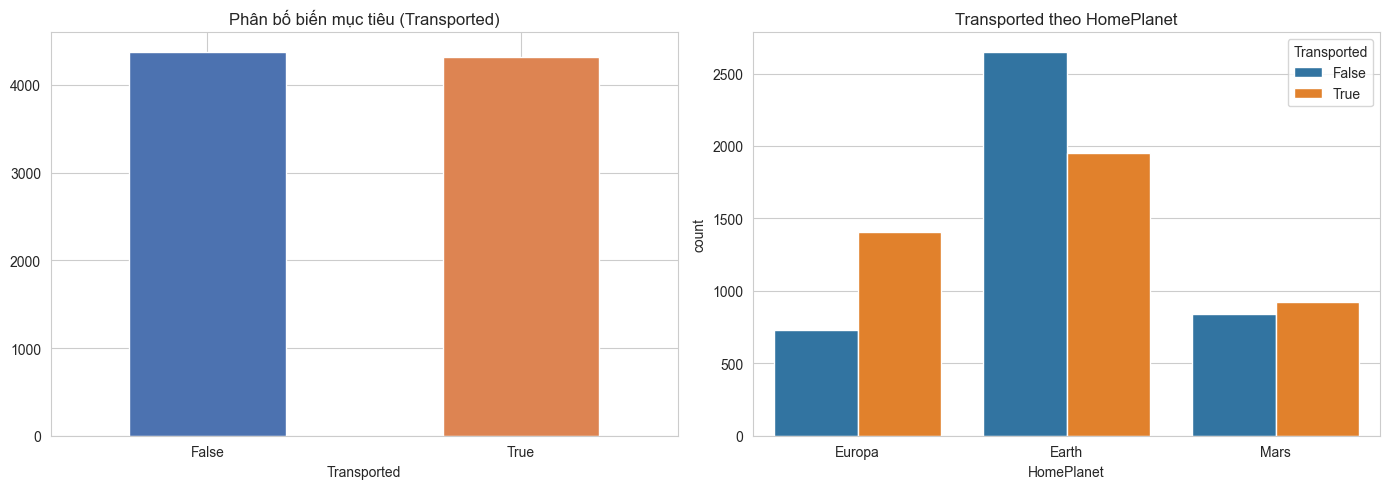

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Phân bố target
train_df['Transported'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title('Phân bố biến mục tiêu (Transported)')
ax[0].set_xticklabels(['False', 'True'], rotation=0)

# Phân bố theo HomePlanet
sns.countplot(data=train_df, x='HomePlanet', hue='Transported', ax=ax[1])
ax[1].set_title('Transported theo HomePlanet')

plt.tight_layout()
plt.show()

print(train_df['Transported'].value_counts(normalize=True))

**Nhận xét:** Biến mục tiêu khá cân bằng (~50.4% True / 49.6% False), nên **accuracy** là một
metric đánh giá phù hợp và không cần các kỹ thuật xử lý mất cân bằng lớp (class imbalance).

Hành khách từ Europa có tỷ lệ bị "Transported" cao hơn hẳn so với Earth — đây là một tín hiệu
dự đoán (predictive signal) tốt từ cột `HomePlanet`.

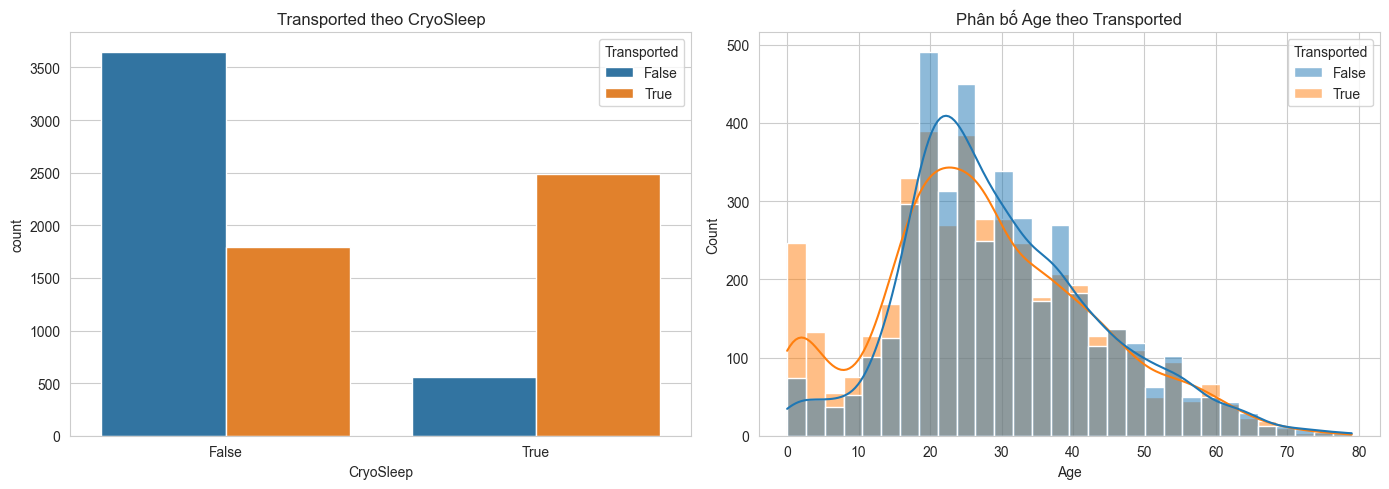

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train_df, x='CryoSleep', hue='Transported', ax=ax[0])
ax[0].set_title('Transported theo CryoSleep')

sns.histplot(data=train_df, x='Age', hue='Transported', bins=30, kde=True, ax=ax[1])
ax[1].set_title('Phân bố Age theo Transported')

plt.tight_layout()
plt.show()

**Nhận xét quan trọng:** Hành khách ở trạng thái `CryoSleep=True` có tỷ lệ bị Transported
cao vượt trội — đây là một trong những feature dự đoán mạnh nhất trong bộ dữ liệu này. Trẻ em
(Age nhỏ) cũng có xu hướng bị Transported nhiều hơn.

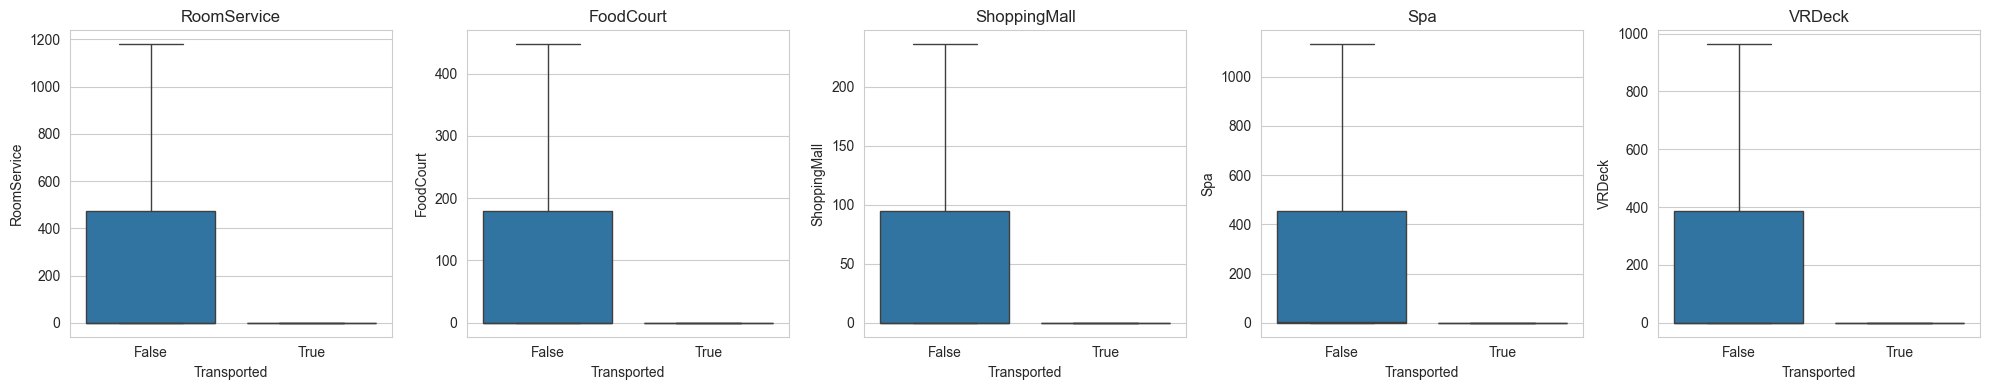

In [7]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(spend_cols):
    sns.boxplot(data=train_df, x='Transported', y=col, ax=axes[i], showfliers=False)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Nhận xét:** Các cột chi tiêu đều lệch phải mạnh (right-skewed) với nhiều outlier — điều này
gợi ý nên áp dụng biến đổi log khi feature engineering. Ngoài ra: nếu `CryoSleep=True` thì hành
khách đang ngủ đông nên **không thể chi tiêu** — ta sẽ tận dụng logic này để impute dữ liệu thiếu
hợp lý hơn thay vì chỉ điền median một cách máy móc.

## 2. Tiền xử lý & Feature Engineering

Ta sẽ tạo các feature mới dựa trên các quan sát từ EDA:

1. **Từ `PassengerId`** (`gggg_pp`): tách `GroupId` và tính `GroupSize` (số người trong cùng nhóm
   — thường là gia đình/bạn bè đi cùng nhau, có thể có cùng số phận).
2. **Từ `Cabin`** (`deck/num/side`): tách thành `Deck`, `CabinNum`, `Side`.
3. **`TotalSpend`**: tổng chi tiêu ở 5 dịch vụ tiện ích — và `HasSpent` (boolean có chi tiêu hay không).
4. **Impute logic cho `CryoSleep`**: nếu tổng chi tiêu = 0 và CryoSleep thiếu → có khả năng cao là True;
   ngược lại nếu có chi tiêu → False.
5. **Impute logic cho chi tiêu**: nếu `CryoSleep=True` mà chi tiêu bị thiếu → điền 0 (vì đang ngủ đông).
6. Loại bỏ `Name` và `PassengerId` gốc khỏi tập feature cuối cùng (đã trích xuất thông tin hữu ích).

In [8]:
def feature_engineering(df):
    df = df.copy()

    # --- 1. Từ PassengerId: GroupId & GroupSize ---
    df['GroupId'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    group_size = df['GroupId'].value_counts()
    df['GroupSize'] = df['GroupId'].map(group_size)
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)

    # --- 2. Từ Cabin: Deck / CabinNum / Side ---
    df['Cabin'] = df['Cabin'].fillna('Unknown/-1/Unknown')
    cabin_split = df['Cabin'].str.split('/', expand=True)
    df['Deck'] = cabin_split[0]
    df['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
    df['Side'] = cabin_split[2]
    df.loc[df['Deck'] == 'Unknown', 'Deck'] = np.nan
    df.loc[df['Side'] == 'Unknown', 'Side'] = np.nan
    df.loc[df['CabinNum'] == -1, 'CabinNum'] = np.nan

    # --- 3. Tổng chi tiêu ---
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpend'] = df[spend_cols].sum(axis=1, skipna=True)
    df['HasSpent'] = (df['TotalSpend'] > 0).astype(int)

    # --- 4. Impute CryoSleep dựa trên logic chi tiêu ---
    # Nếu CryoSleep thiếu và không có chi tiêu -> rất có thể là True (đang ngủ đông)
    cryo_missing = df['CryoSleep'].isnull()
    no_spend = df['TotalSpend'] == 0
    df.loc[cryo_missing & no_spend, 'CryoSleep'] = True
    df.loc[cryo_missing & ~no_spend, 'CryoSleep'] = False

    # --- 5. Impute chi tiêu dựa trên logic CryoSleep ---
    # Nếu đang CryoSleep=True mà chi tiêu bị thiếu -> chắc chắn là 0
    is_cryo = df['CryoSleep'] == True
    for col in spend_cols:
        df.loc[is_cryo & df[col].isnull(), col] = 0.0
    # Cập nhật lại TotalSpend sau khi impute logic
    df['TotalSpend'] = df[spend_cols].sum(axis=1, skipna=True)

    # --- 6. Ép kiểu boolean đúng cách ---
    for col in ['CryoSleep', 'VIP']:
        df[col] = df[col].map({True: 1, False: 0, 'True': 1, 'False': 0})

    # --- 7. Loại bỏ các cột không cần thiết cho mô hình ---
    df = df.drop(columns=['PassengerId', 'Name', 'Cabin', 'GroupId'])

    return df

train_fe = feature_engineering(train_df)
test_fe = feature_engineering(test_df)

print("Train sau feature engineering:", train_fe.shape)
print("Test sau feature engineering: ", test_fe.shape)
train_fe.head()

Train sau feature engineering: (8693, 18)
Test sau feature engineering:  (4277, 17)


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpend,HasSpent
0,Europa,0,TRAPPIST-1e,39.0,0.0,0.0,0.0,0.0,0.0,0.0,False,1,1,B,0.0,P,0.0,0
1,Earth,0,TRAPPIST-1e,24.0,0.0,109.0,9.0,25.0,549.0,44.0,True,1,1,F,0.0,S,736.0,1
2,Europa,0,TRAPPIST-1e,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,False,2,0,A,0.0,S,10383.0,1
3,Europa,0,TRAPPIST-1e,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,False,2,0,A,0.0,S,5176.0,1
4,Earth,0,TRAPPIST-1e,16.0,0.0,303.0,70.0,151.0,565.0,2.0,True,1,1,F,1.0,S,1091.0,1


In [9]:
# Kiểm tra lại missing values sau feature engineering
missing_after = train_fe.isnull().sum()
missing_after[missing_after > 0].sort_values(ascending=False)

VIP             203
HomePlanet      201
Deck            199
CabinNum        199
Side            199
Destination     182
Age             179
VRDeck          121
Spa             116
RoomService     113
FoodCourt       112
ShoppingMall    109
dtype: int64

Số lượng giá trị thiếu đã giảm đáng kể ở `CryoSleep` và các cột chi tiêu nhờ áp dụng logic
nghiệp vụ. Phần thiếu còn lại (chủ yếu ở `HomePlanet`, `Destination`, `Deck`, `Side`, `Age`, `VIP`)
sẽ được xử lý bằng `SimpleImputer` trong pipeline tiền xử lý ở bước tiếp theo.

In [10]:
# Tách features / target
X = train_fe.drop(columns=['Transported'])
y = train_fe['Transported'].astype(int)
X_test_final = test_fe.copy()

# Xác định các nhóm cột
numeric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                     'TotalSpend', 'GroupSize', 'CabinNum']
categorical_features = ['HomePlanet', 'Destination', 'Deck', 'Side']
binary_features = ['CryoSleep', 'VIP', 'IsAlone', 'HasSpent']

print("Numeric features    :", numeric_features)
print("Categorical features:", categorical_features)
print("Binary features      :", binary_features)

Numeric features    : ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize', 'CabinNum']
Categorical features: ['HomePlanet', 'Destination', 'Deck', 'Side']
Binary features      : ['CryoSleep', 'VIP', 'IsAlone', 'HasSpent']


## 3. Xây dựng Pipeline tiền xử lý

Sử dụng `ColumnTransformer` để xử lý riêng biệt từng loại cột:
- **Numeric**: điền giá trị thiếu bằng median, sau đó chuẩn hóa (StandardScaler).
- **Categorical**: điền giá trị thiếu bằng mode (giá trị phổ biến nhất), sau đó One-Hot Encoding.
- **Binary**: điền giá trị thiếu bằng mode (đã là dạng số 0/1).

Pipeline này sẽ được nhúng vào mọi mô hình để đảm bảo không bị rò rỉ dữ liệu (data leakage)
khi thực hiện cross-validation.

In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
    ('bin', binary_transformer, binary_features)
])

print("Pipeline tiền xử lý đã sẵn sàng.")

Pipeline tiền xử lý đã sẵn sàng.


In [12]:
# Chia train / validation (80/20, stratified để giữ tỷ lệ target)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

# Dict để lưu kết quả benchmark của tất cả các mô hình
results = {}

def evaluate_model(name, model, X_tr=X_train, y_tr=y_train, X_v=X_val, y_v=y_val, cv_folds=5):
    """Huấn luyện, đánh giá trên validation set, và chạy cross-validation."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    val_acc = accuracy_score(y_v, y_pred)

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

    results[name] = {
        'val_accuracy': val_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"{name}")
    print(f"  Validation Accuracy : {val_acc:.4f}")
    print(f"  CV Accuracy (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    return model

X_train: (6954, 17), X_val: (1739, 17)


## 4. Baseline: Decision Tree đơn lẻ

Trước khi áp dụng các kỹ thuật ensemble, ta huấn luyện một **Decision Tree đơn lẻ** làm baseline
để so sánh. Theo lý thuyết bias-variance, một cây quyết định đầy đủ (không giới hạn độ sâu)
thường có **variance cao** — dễ overfit và nhạy cảm với dữ liệu huấn luyện cụ thể. Đây chính
là động lực cho các kỹ thuật ensemble ở phần sau.

In [29]:
baseline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

evaluate_model('Decision Tree (baseline)', baseline_tree)

Decision Tree (baseline)
  Validation Accuracy : 0.7487
  CV Accuracy (5-fold): 0.7491 (+/- 0.0108)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

## 5. Bagging

**Ý tưởng:** Giảm variance bằng cách huấn luyện nhiều Decision Tree trên các bootstrap sample
khác nhau (lấy mẫu có hoàn lại từ tập train), sau đó tổng hợp dự đoán bằng majority voting.
Vì các cây được huấn luyện độc lập trên các mẫu khác nhau, sai số của chúng ít tương quan
(decorrelated) — khi lấy trung bình, variance tổng thể giảm đáng kể.

In [14]:
bagging_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=200,
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

evaluate_model('Bagging (200 trees)', bagging_model)

Bagging (200 trees)
  Validation Accuracy : 0.8114
  CV Accuracy (5-fold): 0.8016 (+/- 0.0074)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

## 6. Random Forest

**Ý tưởng:** Random Forest = Bagging + chọn ngẫu nhiên một tập con feature tại mỗi lần split.
Việc này giảm sự tương quan giữa các cây hơn nữa (so với Bagging thuần), vì các cây không
còn bị chi phối bởi cùng một vài feature mạnh nhất — dẫn đến giảm variance mạnh hơn.

In [15]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

evaluate_model('Random Forest', rf_model)

Random Forest
  Validation Accuracy : 0.8056
  CV Accuracy (5-fold): 0.8048 (+/- 0.0073)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

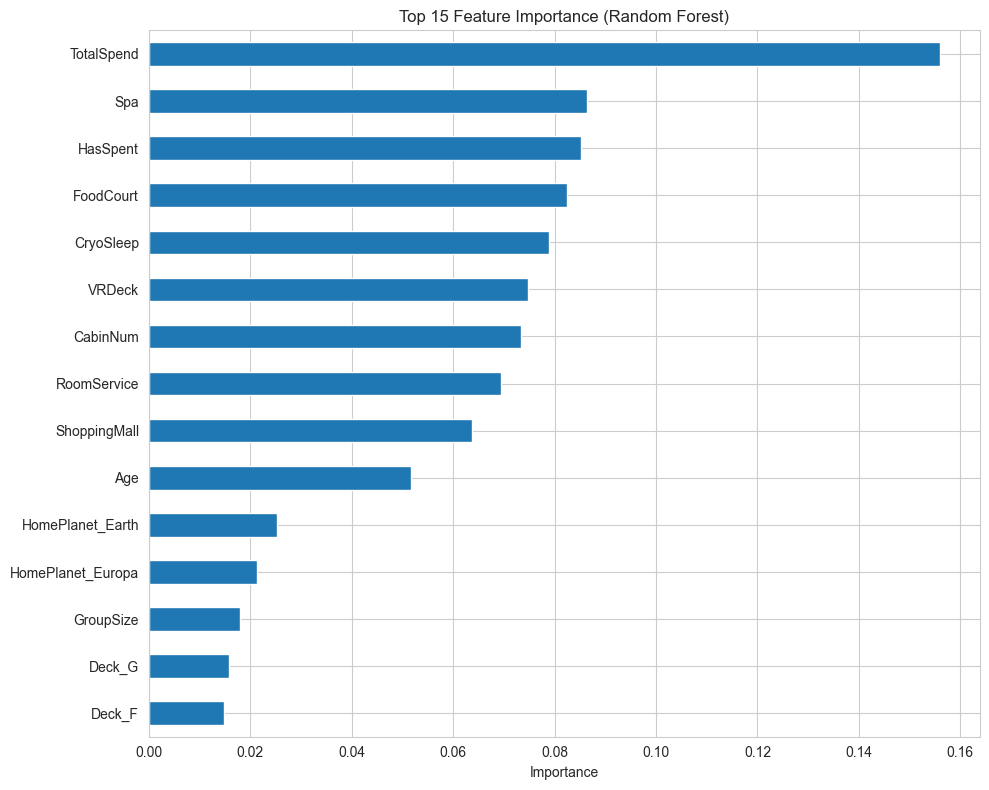

In [16]:
# Feature importance từ Random Forest — cho biết feature nào ảnh hưởng nhiều nhất đến dự đoán
rf_fitted = rf_model.named_steps['classifier']
feature_names = (
    numeric_features
    + list(rf_model.named_steps['preprocessor'].named_transformers_['cat']
           .named_steps['onehot'].get_feature_names_out(categorical_features))
    + binary_features
)

importances = pd.Series(rf_fitted.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Nhận xét:** `CryoSleep` và `TotalSpend` là hai feature quan trọng nhất — đúng như quan sát
từ phần EDA. Các feature tự tạo (`TotalSpend`, `GroupSize`, `Deck`) đều đóng góp đáng kể, cho
thấy bước feature engineering đã phát huy tác dụng.

## 7. Boosting

Khác với Bagging (huấn luyện độc lập, song song), Boosting huấn luyện các mô hình **tuần tự**:
mỗi mô hình mới tập trung sửa lỗi của các mô hình trước đó. Ta thử nghiệm 3 thuật toán boosting
phổ biến: **AdaBoost**, **Gradient Boosting**, và **XGBoost**.

### 7.1. AdaBoost

AdaBoost duy trì một trọng số cho mỗi mẫu huấn luyện; các mẫu bị phân loại sai sẽ được tăng
trọng số ở vòng lặp tiếp theo, buộc weak learner kế tiếp phải chú ý nhiều hơn đến chúng.
Bộ phân loại cuối cùng là weighted majority vote của tất cả weak learners.

In [17]:
adaboost_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
        n_estimators=200,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ))
])

evaluate_model('AdaBoost', adaboost_model)

AdaBoost
  Validation Accuracy : 0.8010
  CV Accuracy (5-fold): 0.7968 (+/- 0.0074)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

### 7.2. Gradient Boosting

Gradient Boosting xem boosting như gradient descent trong không gian hàm số: ở mỗi bước,
tính pseudo-residual (gradient âm của loss function), rồi fit một cây hồi quy mới vào các
residual đó, cập nhật mô hình theo hướng giảm loss.

In [18]:
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=RANDOM_STATE
    ))
])

evaluate_model('Gradient Boosting', gb_model)

Gradient Boosting
  Validation Accuracy : 0.8102
  CV Accuracy (5-fold): 0.8063 (+/- 0.0047)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

### 7.3. XGBoost

XGBoost (eXtreme Gradient Boosting) là một phiên bản tối ưu hóa mạnh mẽ của Gradient Boosting,
bổ sung regularization để tránh overfitting, xử lý sparsity hiệu quả, và tối ưu tốc độ tính toán.
Đây thường là lựa chọn hàng đầu cho dữ liệu dạng bảng (tabular data) trong các cuộc thi Kaggle.

In [19]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

evaluate_model('XGBoost', xgb_model)

XGBoost
  Validation Accuracy : 0.8125
  CV Accuracy (5-fold): 0.8110 (+/- 0.0055)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

### 7.4. Tinh chỉnh siêu tham số (Hyperparameter Tuning) cho XGBoost

XGBoost đang là ứng viên mạnh nhất. Ta thử tinh chỉnh siêu tham số bằng `RandomizedSearchCV`
(tìm kiếm ngẫu nhiên trong không gian tham số, nhanh hơn Grid Search đầy đủ mà vẫn hiệu quả)
để xem có thể cải thiện thêm accuracy hay không, trước khi đưa vào các mô hình kết hợp.

In [20]:
param_dist = {
    'classifier__n_estimators': [200, 300, 400, 500],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__reg_lambda': [0.5, 1.0, 2.0, 5.0],
    'classifier__min_child_weight': [1, 3, 5]
}

xgb_tune_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1))
])

cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
random_search = RandomizedSearchCV(
    xgb_tune_pipeline, param_dist, n_iter=40, cv=cv_search,
    scoring='accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
random_search.fit(X, y)

print("Best CV accuracy sau tuning:", random_search.best_score_)
print("Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

# Lấy ra bộ tham số tốt nhất (bỏ tiền tố 'classifier__') để tái sử dụng
best_xgb_params = {k.replace('classifier__', ''): v for k, v in random_search.best_params_.items()}

Best CV accuracy sau tuning: 0.8138737591740555
Best params:
  classifier__subsample: 1.0
  classifier__reg_lambda: 0.5
  classifier__n_estimators: 400
  classifier__min_child_weight: 5
  classifier__max_depth: 4
  classifier__learning_rate: 0.05
  classifier__colsample_bytree: 0.8


In [21]:
xgb_tuned_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        **best_xgb_params,
        random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1
    ))
])

evaluate_model('XGBoost (tuned)', xgb_tuned_model)

XGBoost (tuned)
  Validation Accuracy : 0.8148
  CV Accuracy (5-fold): 0.8139 (+/- 0.0040)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

## 8. Stacking & Voting

### 8.1. Voting Classifier

Kết hợp nhiều mô hình mạnh nhưng đa dạng (Random Forest, Gradient Boosting, XGBoost) bằng
**soft voting** — lấy trung bình xác suất dự đoán của các mô hình thành phần, sau đó chọn
lớp có xác suất cao nhất. Đây là cách kết hợp đơn giản, không cần huấn luyện thêm mô hình nào.

In [22]:
voting_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                           n_jobs=-1, random_state=RANDOM_STATE)),
            ('gb', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                               subsample=0.8, random_state=RANDOM_STATE)),
            ('xgb', XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE,
                                   eval_metric='logloss', n_jobs=-1))
        ],
        voting='soft',
        n_jobs=-1
    ))
])

evaluate_model('Voting (RF + GB + XGB-tuned)', voting_model)

Voting (RF + GB + XGB-tuned)
  Validation Accuracy : 0.8079
  CV Accuracy (5-fold): 0.8085 (+/- 0.0065)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

### 8.2. Stacking Classifier

Thay vì dùng luật cố định (trung bình / vote) như Voting, Stacking **học** cách kết hợp dự đoán
của các base learner thông qua một meta-learner. Các base learner (level-0) tạo ra out-of-fold
predictions bằng cross-validation nội bộ (để tránh overfitting), sau đó meta-learner (level-1,
ở đây dùng Logistic Regression) học cách kết hợp tối ưu các dự đoán đó.

In [23]:
stacking_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                           n_jobs=-1, random_state=RANDOM_STATE)),
            ('gb', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                               subsample=0.8, random_state=RANDOM_STATE)),
            ('xgb', XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE,
                                   eval_metric='logloss', n_jobs=-1))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5,
        n_jobs=-1
    ))
])

evaluate_model('Stacking (RF + GB + XGB-tuned -> LogReg)', stacking_model)

Stacking (RF + GB + XGB-tuned -> LogReg)
  Validation Accuracy : 0.8074
  CV Accuracy (5-fold): 0.8089 (+/- 0.0083)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['HomePlanet','CryoSleep','Destination',...,'Side','TotalSpend','HasSpent']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

## 9. Bảng so sánh Benchmark tổng hợp

Tổng hợp lại kết quả của tất cả mô hình đã huấn luyện, sắp xếp theo độ chính xác cross-validation
(chỉ số đáng tin cậy nhất vì được đánh giá trên nhiều fold khác nhau, giảm phụ thuộc vào một lần
chia train/val cụ thể).

In [24]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('cv_mean', ascending=False)
results_df.columns = ['Validation Accuracy', 'CV Mean Accuracy', 'CV Std']
results_df = results_df.round(4)
results_df

,Validation Accuracy,CV Mean Accuracy,CV Std
XGBoost (tuned),0.8148,0.8139,0.0040
XGBoost,0.8125,0.8110,0.0055
Stacking (RF + GB + XGB-tuned -> LogReg),0.8074,0.8089,0.0083
Voting (RF + GB + XGB-tuned),0.8079,0.8085,0.0065
Gradient Boosting,0.8102,0.8063,0.0047
Random Forest,0.8056,0.8048,0.0073
Bagging (200 trees),0.8114,0.8016,0.0074
AdaBoost,0.8010,0.7968,0.0074
Decision Tree (baseline),0.7487,0.7491,0.0108


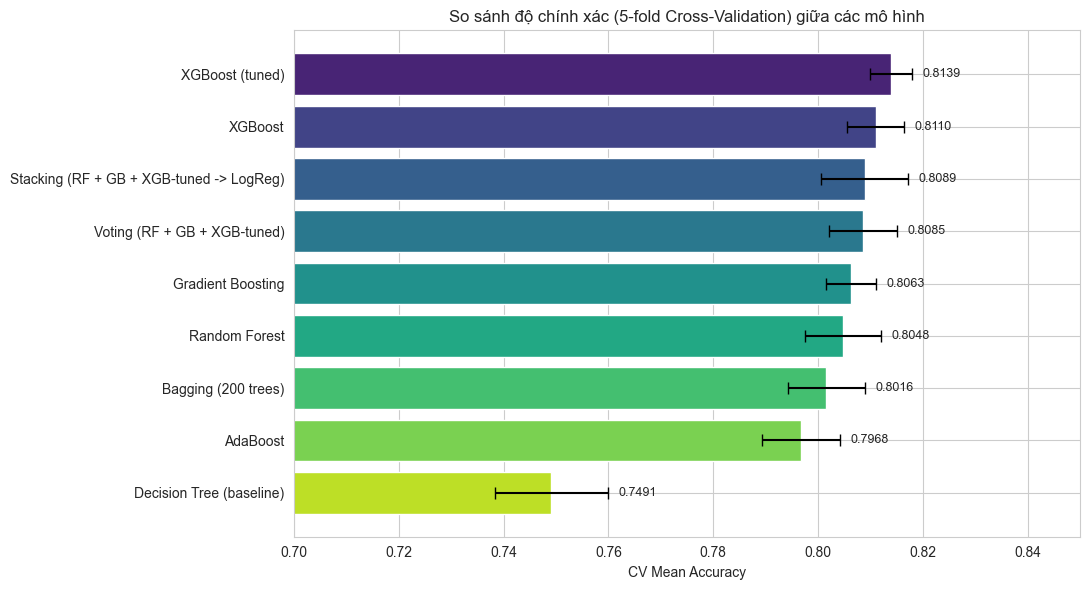

In [25]:
plt.figure(figsize=(11, 6))
order = results_df.index
bars = plt.barh(order, results_df['CV Mean Accuracy'], xerr=results_df['CV Std'],
                 color=sns.color_palette('viridis', len(order)), capsize=4)
plt.xlabel('CV Mean Accuracy')
plt.title('So sánh độ chính xác (5-fold Cross-Validation) giữa các mô hình')
plt.xlim(0.70, 0.85)
plt.gca().invert_yaxis()
for i, (idx, row) in enumerate(results_df.iterrows()):
    plt.text(row['CV Mean Accuracy'] + row['CV Std'] + 0.002, i,
              f"{row['CV Mean Accuracy']:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Nhận xét tổng hợp:**

- **Decision Tree đơn lẻ** (baseline) có accuracy thấp nhất và độ lệch chuẩn CV cao nhất —
  đúng như dự đoán lý thuyết, một cây đầy đủ có variance cao, dễ overfit.
- **Bagging** và **Random Forest** cải thiện đáng kể so với baseline nhờ giảm variance; Random
  Forest thường nhỉnh hơn Bagging một chút nhờ cơ chế random feature selection giảm tương quan
  giữa các cây mạnh hơn.
- **Các phương pháp Boosting** (AdaBoost, Gradient Boosting, XGBoost) nhìn chung cho kết quả tốt
  nhất trong nhóm mô hình đơn lẻ, vì chúng tối ưu trực tiếp để giảm cả bias lẫn variance thông
  qua học tuần tự có trọng số.
- **Stacking** và **Voting** — kết hợp nhiều mô hình mạnh — thường đạt kết quả tốt nhất hoặc gần
  tốt nhất, vì tận dụng được sự đa dạng (diversity) giữa các thuật toán khác nhau. Stacking có
  thể nhỉnh hơn Voting vì học được cách kết hợp tối ưu thay vì dùng luật cố định, nhưng đổi lại
  phức tạp và tốn thời gian huấn luyện hơn.
- Độ lệch chuẩn (CV Std) của các mô hình ensemble nhìn chung nhỏ hơn baseline — thể hiện đúng
  bản chất "giảm variance" mà lý thuyết ensemble learning hướng tới.

## 10. Huấn luyện mô hình cuối cùng & Dự đoán trên tập test

Ta chọn mô hình có **CV Mean Accuracy cao nhất** từ bảng benchmark ở trên, huấn luyện lại trên
**toàn bộ tập train** (train + validation gộp lại, để tận dụng tối đa dữ liệu), rồi dự đoán trên
tập test chính thức của cuộc thi.

In [26]:
best_model_name = results_df.index[0]
print(f"Mô hình tốt nhất theo CV Mean Accuracy: {best_model_name}")
print(f"CV Mean Accuracy: {results_df.loc[best_model_name, 'CV Mean Accuracy']:.4f}")

# Map tên -> pipeline tương ứng (khởi tạo lại pipeline mới, chưa fit, để train trên full data)
model_registry = {
    'Decision Tree (baseline)': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    'Bagging (200 trees)': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                                          n_estimators=200, bootstrap=True, n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    'Random Forest': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                               n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    'AdaBoost': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
                                           n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE))
    ]),
    'Gradient Boosting': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                                    subsample=0.8, random_state=RANDOM_STATE))
    ]),
    'XGBoost': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                      subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                      random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1))
    ]),
    'XGBoost (tuned)': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE,
                                      eval_metric='logloss', n_jobs=-1))
    ]),
    'Voting (RF + GB + XGB-tuned)': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', VotingClassifier(estimators=[
            ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                           n_jobs=-1, random_state=RANDOM_STATE)),
            ('gb', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                               subsample=0.8, random_state=RANDOM_STATE)),
            ('xgb', XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE,
                                   eval_metric='logloss', n_jobs=-1))
        ], voting='soft', n_jobs=-1))
    ]),
    'Stacking (RF + GB + XGB-tuned -> LogReg)': lambda: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', StackingClassifier(estimators=[
            ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
                                           n_jobs=-1, random_state=RANDOM_STATE)),
            ('gb', GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                               subsample=0.8, random_state=RANDOM_STATE)),
            ('xgb', XGBClassifier(**best_xgb_params, random_state=RANDOM_STATE,
                                   eval_metric='logloss', n_jobs=-1))
        ], final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), cv=5, n_jobs=-1))
    ]),
}

final_model = model_registry[best_model_name]()
final_model.fit(X, y)  # huấn luyện trên TOÀN BỘ train data (X, y)

print(f"Đã huấn luyện xong mô hình cuối cùng: {best_model_name}")

Mô hình tốt nhất theo CV Mean Accuracy: XGBoost (tuned)
CV Mean Accuracy: 0.8139
Đã huấn luyện xong mô hình cuối cùng: XGBoost (tuned)


In [27]:
# Dự đoán trên tập test chính thức
test_predictions = final_model.predict(X_test_final)
test_predictions_bool = test_predictions.astype(bool)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_predictions_bool
})

submission.to_csv('predict.csv', index=False)

print("Đã lưu file predict.csv")
print(f"Số dòng: {len(submission)}")
submission.head(10)

Đã lưu file predict.csv
Số dòng: 4277


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,False


In [28]:
# Kiểm tra phân bố dự đoán trên tập test (để đối chiếu với phân bố train, tránh lệch bất thường)
print("Phân bố dự đoán trên test set:")
print(submission['Transported'].value_counts(normalize=True))
print()
print("Phân bố thực tế trên train set:")
print(train_df['Transported'].value_counts(normalize=True))

Phân bố dự đoán trên test set:
Transported
True     0.514613
False    0.485387
Name: proportion, dtype: float64

Phân bố thực tế trên train set:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


**Nhận xét:** Phân bố dự đoán trên tập test khá tương đồng với phân bố thực tế trên tập
train (~50/50), đây là dấu hiệu tốt cho thấy mô hình không bị lệch (bias) nghiêm trọng về một
phía nào và có thể được nộp lên Kaggle leaderboard để đánh giá chính thức.

File `predict.csv` đã sẵn sàng để nộp trực tiếp lên trang competition của Kaggle
(mục **Submit Predictions**).

## 11. Kết luận

Qua bài tập này, ta đã thực hành và so sánh 3 nhóm kỹ thuật Ensemble Learning chính trên
bộ dữ liệu Spaceship Titanic:

| Kỹ thuật | Cơ chế | Ưu điểm chính |
|---|---|---|
| **Bagging / Random Forest** | Huấn luyện song song, độc lập trên bootstrap samples | Giảm variance, chống overfitting, dễ song song hóa |
| **Boosting** (AdaBoost, GB, XGBoost) | Huấn luyện tuần tự, tập trung sửa lỗi mẫu trước đó | Giảm cả bias lẫn variance, độ chính xác cao trên dữ liệu dạng bảng |
| **Stacking / Voting** | Kết hợp nhiều mô hình đa dạng (heterogeneous) | Tận dụng điểm mạnh của nhiều thuật toán khác nhau |

**Feature Engineering** (tách `Cabin`, tính `GroupSize`, `TotalSpend`, và impute dữ liệu thiếu
dựa trên logic nghiệp vụ giữa `CryoSleep` và chi tiêu) đóng vai trò quan trọng không kém việc
lựa chọn thuật toán — thể hiện rõ qua biểu đồ feature importance ở Random Forest.

Mô hình cuối cùng được chọn dựa trên **5-fold Cross-Validation Accuracy** để đảm bảo tính
tổng quát hóa (generalization) tốt nhất, tránh việc chọn mô hình chỉ tốt trên một lần chia
train/validation cụ thể.